# WSTĘPNA ANALIZA ZBIORU DANYCH

###  Telco Customer Churn

In [ ]:

from copy import deepcopy

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from constants import (
    CATEGORICAL_COLUMNS,
    CHURN,
    CONTRACT,
    CUSTOMER_ID,
    DATA_FILE,
    DEPENDENTS,
    DEVICE_PROTECTION,
    GENDER,
    INTERNET_SERVICE,
    MONTHLY_CHARGES,
    MULTIPLE_LINES,
    NUMERIC_COLUMNS,
    ONLINE_BACKUP,
    ONLINE_SECURITY,
    PAPERLESS_BILLING,
    PARTNER,
    PAYMENT_METHOD,
    PHONE_SERVICE,
    STREAMING_MOVIES,
    STREAMING_TV,
    TECH_SUPPORT,
    TENURE,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Plik z danymi:", DATA_FILE)


Plik z danymi: resources\WA_Fn-UseC_-Telco-Customer-Churn.csv


## Załadowanie pliku i EDA

In [118]:
data = pd.read_csv(DATA_FILE)

for column in NUMERIC_COLUMNS:
    data[column] = pd.to_numeric(data[column], errors="coerce")
    

def numeric_statistics(df: pd.DataFrame) -> pd.DataFrame:
    numeric_data = df[NUMERIC_COLUMNS]

    statistics = pd.DataFrame(
        {
            "srednia": numeric_data.mean(),
            "mediana": numeric_data.median(),
            "min": numeric_data.min(),
            "max": numeric_data.max(),
            "odchylenie_standardowe": numeric_data.std(),
        }
    )

    return pd.DataFrame(statistics.round(2))


print("Pierwsze 5 wierszy:")
display(data.head())

print("Informacje o kolumnach:")
data.info()

print("Podstawowe statystyki dla cech numerycznych z pandas:")
display(data[NUMERIC_COLUMNS].describe().round(2))

print("podstawowe obliczone ręcznie statystkiki dla cech numerycznych")
display(numeric_statistics(data))



Pierwsze 5 wierszy:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Informacje o kolumnach:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,7043.00,7043.00,7032.00,7043.00
mean,32.37,64.76,2283.30,0.16
std,24.56,30.09,2266.77,0.37
min,0.00,18.25,18.80,0.00
25%,9.00,35.50,401.45,0.00
50%,29.00,70.35,1397.48,0.00
75%,55.00,89.85,3794.74,0.00
max,72.00,118.75,8684.80,1.00


podstawowe obliczone ręcznie statystkiki dla cech numerycznych


,srednia,mediana,min,max,odchylenie_standardowe
tenure,32.37,29.00,0.00,72.00,24.56
MonthlyCharges,64.76,70.35,18.25,118.75,30.09
TotalCharges,2283.30,1397.48,18.80,8684.80,2266.77
SeniorCitizen,0.16,0.00,0.00,1.00,0.37


## Wybrane ciekawe zależności i dane

In [119]:
def tenure_histogram(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=TENURE, bins=20, color="skyblue", edgecolor="black")
    plt.title("Histogram: czas trwania umowy")
    plt.xlabel("czas trwania umowy")
    plt.ylabel("Liczba klientow")
    plt.tight_layout()
    plt.show()


def tenure_churn_boxplot(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=CHURN, y=TENURE)
    plt.title("Boxplot: czas trwania umowy wzgledem rezygnacji")
    plt.xlabel("Rezygnacja")
    plt.ylabel("czas trwania umowy")
    plt.tight_layout()
    plt.show()


def monthly_charges_histogram(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=MONTHLY_CHARGES, bins=20, color="orange", edgecolor="black")
    plt.title("Histogram: miesieczna oplata")
    plt.xlabel("miesieczna oplata")
    plt.ylabel("Liczba klientow")
    plt.tight_layout()
    plt.show()


def monthly_charges_churn_boxplot(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=CHURN, y=MONTHLY_CHARGES)
    plt.title("Boxplot: miesieczna oplata wzgledem rezygnacji")
    plt.xlabel("Rezygnacja")
    plt.ylabel("miesieczna oplata")
    plt.tight_layout()
    plt.show()


def tenure_monthly_charges_scatter(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=TENURE, y=MONTHLY_CHARGES, hue=CHURN, alpha=0.7)
    plt.title("Wykres rozrzutu: czas trwania umowy i miesieczna oplata")
    plt.xlabel("czas trwania umowy")
    plt.ylabel("miesieczna oplata")
    plt.legend(title="Rezygnacja")
    plt.tight_layout()
    plt.show()


## Dlaczego te 5 wykresow

- `tenure` - pokazuje, jak dlugo klient korzysta z uslug. Nowi klienci zwykle czesciej rezygnuja.
- `MonthlyCharges` - pokazuje miesieczny koszt uslug. Wysoka oplata moze zwiekszac ryzyko odejscia.
- `tenure` vs `Churn` - pozwala sprawdzic, czy klienci odchodzacy maja krotszy czas korzystania z uslug.
- `MonthlyCharges` vs `Churn` - pokazuje, czy osoby odchodzace placa wiecej niz pozostali klienci.
- `tenure` vs `MonthlyCharges` - pozwala zobaczyc zaleznosc miedzy dlugoscia umowy i wysokoscia oplat.


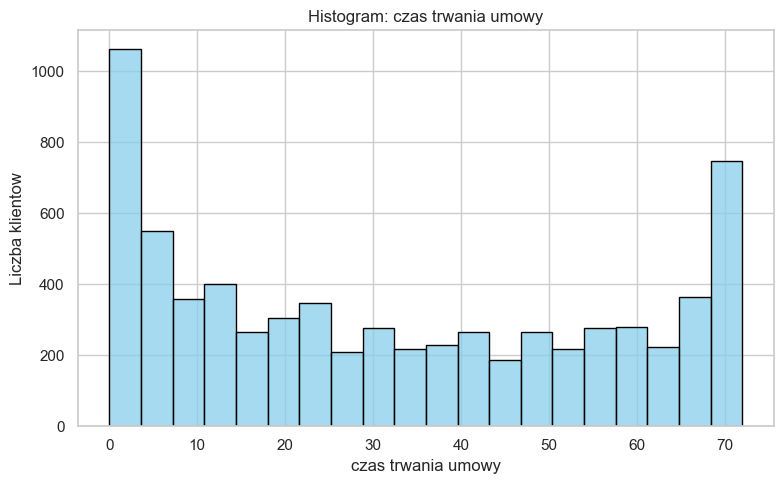

In [120]:
tenure_histogram(data)


Histogram wykazuje rozkład bimodalny. Najliczniejsze grupy stanowią nowi klienci (0-5 miesięcy) oraz klienci długoterminowi (powyżej 65 miesięcy).


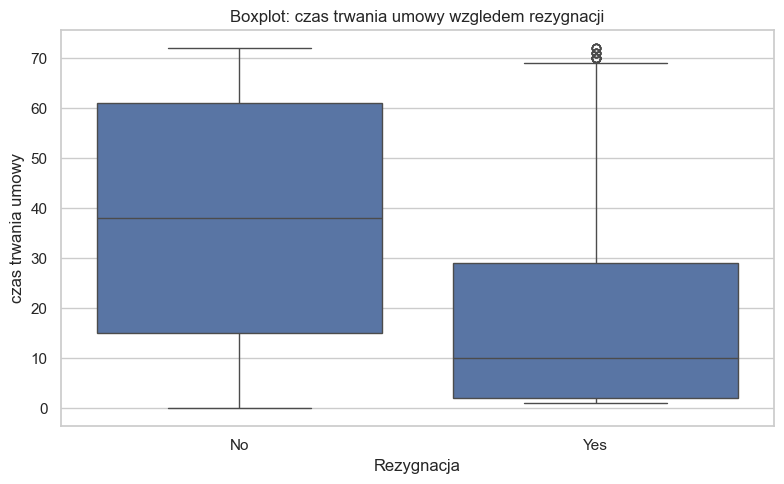

In [121]:
tenure_churn_boxplot(data)


Mediana stażu umowy dla osób rezygnujących (ok. 10 mies.) jest drastycznie niższa niż dla osób pozostających (ok. 38 mies.). 75% wszystkich odejść następuje przed upływem 30 miesiąca trwania umowy.

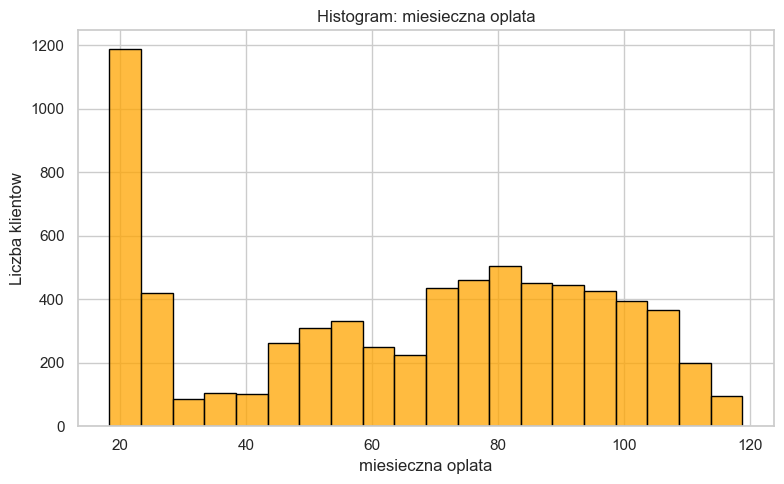

In [122]:
monthly_charges_histogram(data)


 Wyraźna segmentacja klientów na dwie grupy: "Low-tier" (opłaty ok. 20 zł) oraz "High-tier" (opłaty 70-100 zł) Bardzo mała liczebność segmentu średniego (40-60 zł).
 

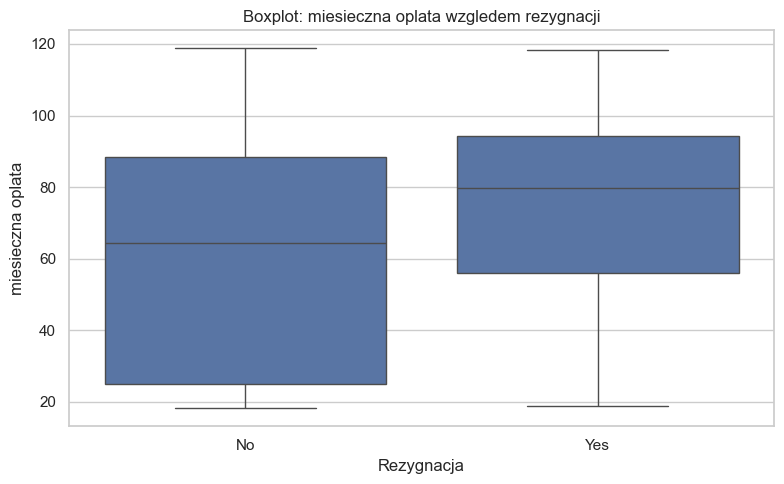

In [123]:
monthly_charges_churn_boxplot(data)


Klienci rezygnujący płacą średnio o ok. 25% wyższe stawki miesięczne niż klienci lojalni (mediana ok. 80 zł vs 65 zł).

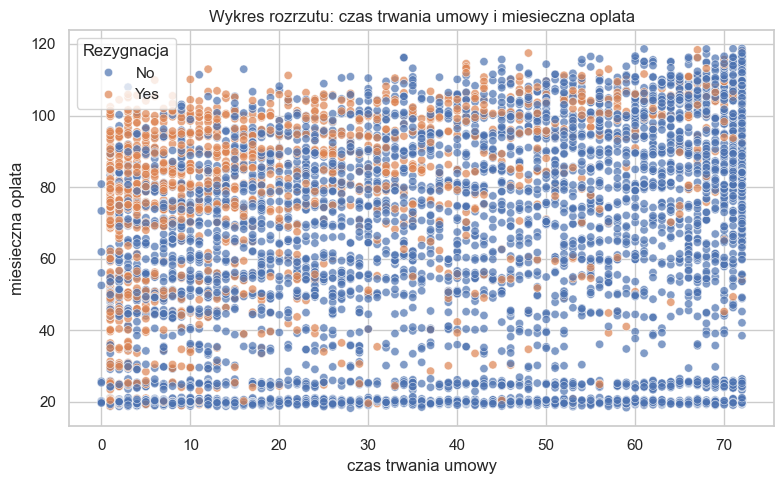

In [124]:
tenure_monthly_charges_scatter(data)


Największa gęstość rezygnacji (punkty pomarańczowe) występuje w obszarze krótkiego stażu i wysokich opłat (lewy górny róg wykresu).

## wniosek

Najbardziej obiecujace cechy to `tenure` (czas trwania umowy) i `MonthlyCharges` (opłaty miesięczne), bo bezposrednio pokazuja, jak dlugo klient zostaje i ile placi. To zwykle pomaga zrozumiec, kto ma wieksze ryzyko rezygnacji.


## Podział na training set i test set

In [125]:
from sklearn.model_selection import train_test_split

train_df: pd.DataFrame
test_df: pd.DataFrame

train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data[CHURN])
display(train_df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3738,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
3151,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
4860,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3867,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,No
3810,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No


## EDA na danych kategorialnych

In [126]:
categorial_df = train_df[CATEGORICAL_COLUMNS]


def get_categorial_stats(df: pd.DataFrame) -> pd.DataFrame:
    basic_stats = df.describe().round(2)
    top_prop = pd.DataFrame((basic_stats.loc['freq'] / basic_stats.loc['count'] * 100).round(2)).T
    top_prop.index = ['top_share_%']
    full_eda = pd.concat([basic_stats, top_prop], axis=0)
    return full_eda


categorial_df.info()
display(get_categorial_stats(categorial_df))


<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gender            5634 non-null   str  
 1   Partner           5634 non-null   str  
 2   Dependents        5634 non-null   str  
 3   PhoneService      5634 non-null   str  
 4   MultipleLines     5634 non-null   str  
 5   InternetService   5634 non-null   str  
 6   OnlineSecurity    5634 non-null   str  
 7   OnlineBackup      5634 non-null   str  
 8   DeviceProtection  5634 non-null   str  
 9   TechSupport       5634 non-null   str  
 10  StreamingTV       5634 non-null   str  
 11  StreamingMovies   5634 non-null   str  
 12  Contract          5634 non-null   str  
 13  PaperlessBilling  5634 non-null   str  
 14  PaymentMethod     5634 non-null   str  
dtypes: str(15)
memory usage: 704.2 KB


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,2833,2905,3955,5075,2685,2483,2797,2442,2472,2771,2226,2217,3102,3331,1891
top_share_%,50.28,51.56,70.2,90.08,47.66,44.07,49.65,43.34,43.88,49.18,39.51,39.35,55.06,59.12,33.56


In [127]:

def plot_encoded_categorical_feature(
    df: pd.DataFrame,
    column: str,
    title: str,
    tick_labels: list[str],
) -> None:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=column, hue=CHURN)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Liczba klientow")
    plt.xticks(ticks=range(len(tick_labels)), labels=tick_labels, rotation=20)
    plt.tight_layout()
    plt.show()


selected_categorical_features = [
    CONTRACT,
    INTERNET_SERVICE,
    PAYMENT_METHOD,
    TECH_SUPPORT,
    ONLINE_SECURITY,
]




### Krotkie uzasadnienie

- `Contract` - umowa miesieczna zwykle oznacza wieksze ryzyko rezygnacji i daje prostą regule decyzyjna.
- `InternetService` - rodzaj internetu moze wskazywac na roznice w cenie i jakosci uslugi.
- `PaymentMethod` - sposob platnosci czesto dzieli bardziej stabilnych i mniej stabilnych klientow.
- `TechSupport` - brak wsparcia technicznego moze zwiekszac frustracje i rezygnacje.
- `OnlineSecurity` - dodatkowe zabezpieczenia moga zmniejszac ryzyko odejscia klienta.


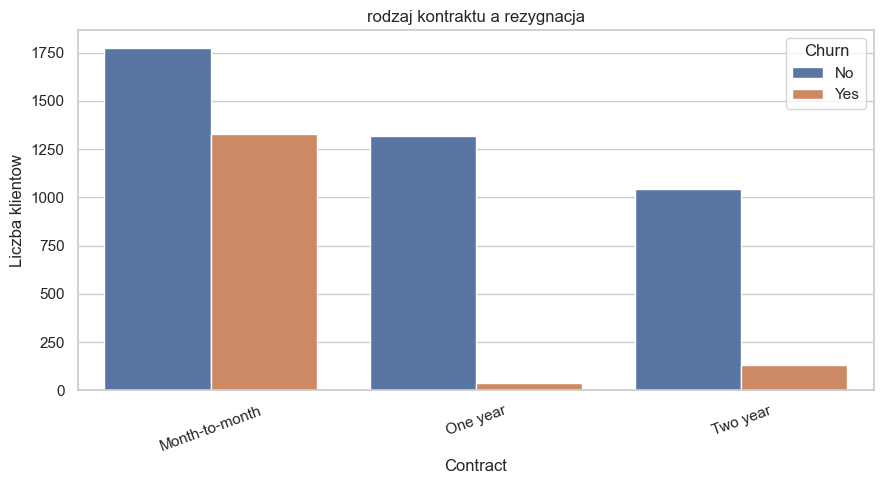

In [128]:
plot_encoded_categorical_feature(
	train_df,
	CONTRACT,
	"rodzaj kontraktu a rezygnacja",
	["Month-to-month", "One year", "Two year"],
)


Typ umowy (Contract) wykazuje silną zależność z rezygnacją. Najwyższy wskaźnik Churn dotyczy umów Month-to-month, co potwierdza, że brak długoterminowego zobowiązania jest kluczowym predyktorem odejścia

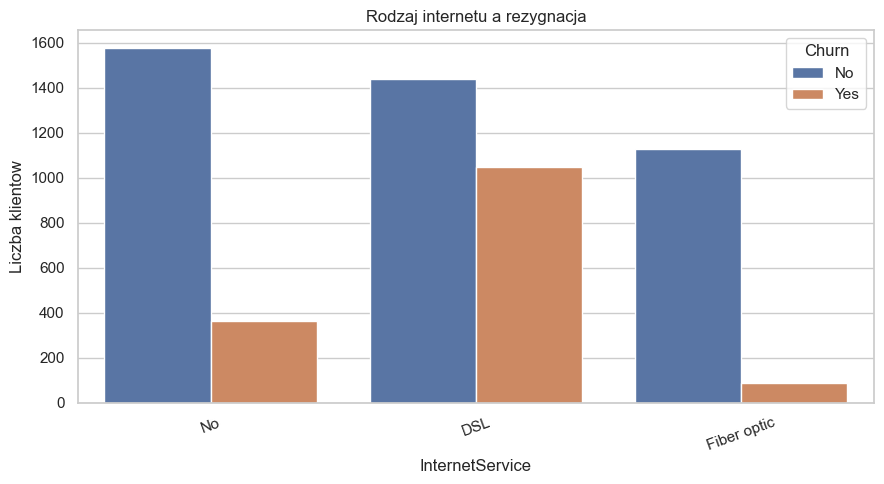

In [129]:
plot_encoded_categorical_feature(
    train_df,
    INTERNET_SERVICE,
    "Rodzaj internetu a rezygnacja",
    ["No", "DSL", "Fiber optic"],
)


Użytkownicy Fiber optic (światłowód) odchodzą znacznie częściej niż pozostali. Liczba rezygnacji w tej grupie jest niemal zbliżona do liczby osób, które zostają. Z kolei osoby bez internetu (No) odchodzą sporadycznie.

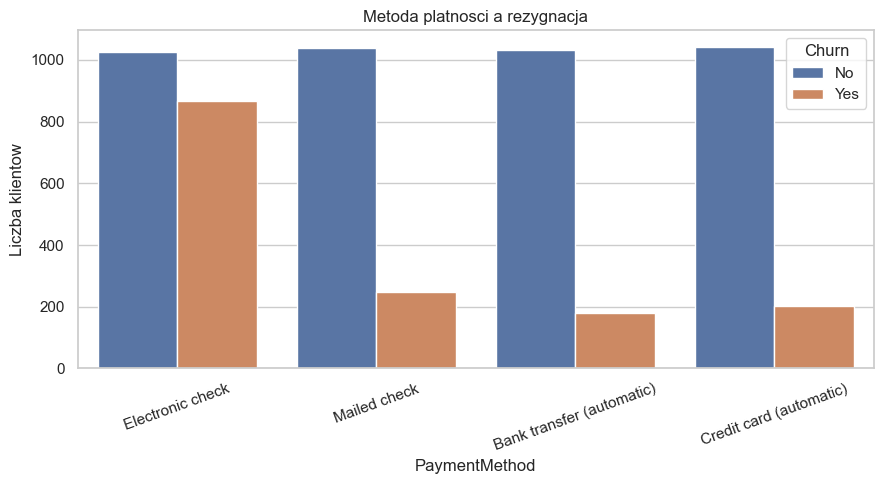

In [130]:
plot_encoded_categorical_feature(
    train_df,
    PAYMENT_METHOD,
    "Metoda platnosci a rezygnacja",
    ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"],
)


Metoda Electronic check wyróżnia się na tle innych drastycznie wysokim słupkiem rezygnacji. Pozostałe metody (przelewy automatyczne czy karta) wykazują znacznie większą lojalność klientów.

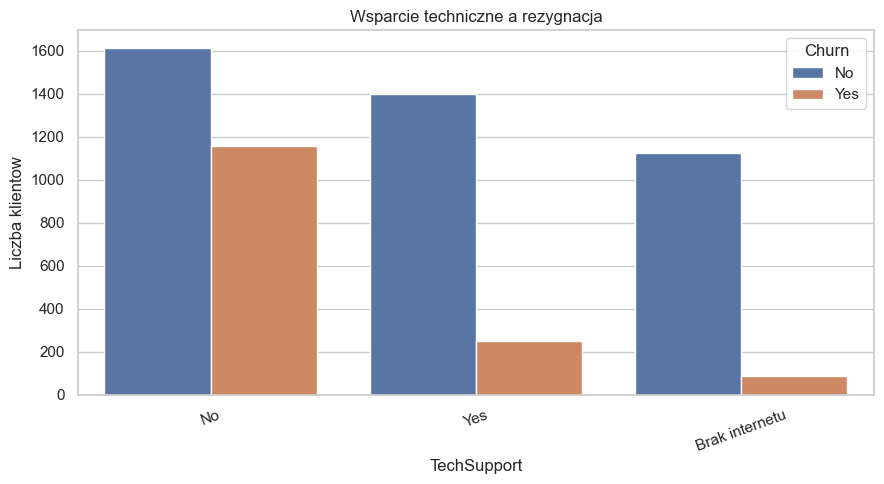

In [131]:
plot_encoded_categorical_feature(train_df,
                                 TECH_SUPPORT, 
                                 "Wsparcie techniczne a rezygnacja", 
                                 ["No", "Yes", "Brak internetu"])


Osoby, które nie korzystają z wsparcia technicznego (No), rezygnują masowo. Z kolei klienci mający zapewniony TechSupport (Yes) odchodzą rzadko.

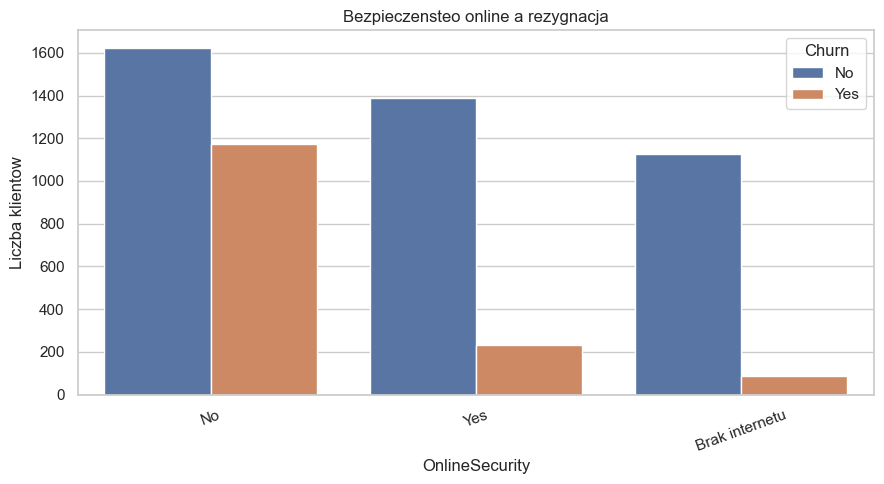

In [132]:
plot_encoded_categorical_feature(train_df,
                                 ONLINE_SECURITY, 
                                 "Bezpieczensteo online a rezygnacja", 
                                 ["No", "Yes", "Brak internetu"])


Wykres jest niemal identyczny jak w przypadku TechSupport. Brak usługi OnlineSecurity drastycznie zwiększa prawdopodobieństwo rezygnacji.

## Kodowanie cech tekstowych na liczby

W tej czesci zamieniam wszystkie kolumny tekstowe z `train_df` na liczby.Dla prostych cech binarnych używam prostego ręcznego mapowania No=0, Yes=1, inna_opca = 2. Dla większej ilości możliwych wyników Uzywam `pd.factorize`, bo to najprostszy sposob, zeby zakodowac kazda wartosc stringowa na liczbe.

To jest osobna kopia danych, wiec wykresy i wczesniejsza analiza nadal korzystaja z oryginalnych napisow.


In [ ]:

def apply_mapping(df: pd.DataFrame, columns: list[str], mapping: dict[str, int]) -> pd.DataFrame:
    for column in columns:
        if column in df.columns:
            df[column] = df[column].map(mapping)
    return df


def factorize_columns(
    train_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    columns: list[str],
    excluded_columns: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, dict[str, int]]]:
    mappings: dict[str, dict[str, int]] = {}
    useful_columns = [column for column in columns if column not in excluded_columns]

    for column in useful_columns:
        train_frame[column], unique_values = pd.factorize(train_frame[column])
        mappings[column] = {value: code for code, value in enumerate(unique_values)}

    for column, mapping in mappings.items():
        if column in test_frame.columns:
            test_frame[column] = test_frame[column].map(mapping)

    return train_frame, test_frame, mappings


encoded_train_df = train_df.copy()
encoded_test_df = test_df.copy()

string_columns = encoded_train_df.select_dtypes(include=["object", "string"]).columns.tolist()
string_columns = [column for column in string_columns if column != CUSTOMER_ID]

binary_cols = [PARTNER, DEPENDENTS, PAPERLESS_BILLING, PHONE_SERVICE, CHURN]
binary_cols_ns = [ONLINE_SECURITY, ONLINE_BACKUP, DEVICE_PROTECTION, TECH_SUPPORT, STREAMING_TV, STREAMING_MOVIES]
binary_cols_ps = [MULTIPLE_LINES]
factorized_cols = string_columns

binary_mapping = {"No": 0, "Yes": 1}
binary_mapping_ns = {"No": 0, "Yes": 1, "No internet service": 2}
binary_mapping_ps = {"No": 0, "Yes": 1, "No phone service": 2}

encoded_train_df = apply_mapping(encoded_train_df, binary_cols, binary_mapping)
encoded_test_df = apply_mapping(encoded_test_df, binary_cols, binary_mapping)

encoded_train_df = apply_mapping(encoded_train_df, binary_cols_ns, binary_mapping_ns)
encoded_test_df = apply_mapping(encoded_test_df, binary_cols_ns, binary_mapping_ns)

encoded_train_df = apply_mapping(encoded_train_df, binary_cols_ps, binary_mapping_ps)
encoded_test_df = apply_mapping(encoded_test_df, binary_cols_ps, binary_mapping_ps)

encoded_train_df, encoded_test_df, string_mappings = factorize_columns(
    encoded_train_df,
    encoded_test_df,
    factorized_cols,
    binary_cols + binary_cols_ns + binary_cols_ps,
)

print("Kolumny tekstowe zakodowane na liczby:")
print(string_columns)

display(encoded_train_df.head())
display(encoded_test_df.head())


Kolumny tekstowe zakodowane na liczby:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3738,4950-BDEUX,0,0,0,0,35,0,2,0,0,...,1,0,1,1,0,0,0,49.20,1701.65,0
3151,7993-NQLJE,0,0,1,1,15,1,0,1,1,...,0,0,0,0,0,0,1,75.10,1151.55,0
4860,7321-ZNSLA,0,0,1,1,13,0,2,0,1,...,0,1,0,0,1,0,1,40.55,590.35,0
3867,4922-CVPDX,1,0,1,0,26,1,0,0,0,...,1,0,1,1,1,1,2,73.50,1905.70,0
3810,2903-YYTBW,0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,44.55,44.55,0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
437,4376-KFVRS,0,0,1,1,72,1,1,1,1,...,1,1,1,1,1,1,2,114.05,8468.20,0
2280,2754-SDJRD,1,1,0,0,8,1,1,1,0,...,0,1,1,1,0,1,2,100.15,908.55,0
2235,9917-KWRBE,1,0,1,1,41,1,1,0,1,...,1,0,1,0,2,1,2,78.35,3211.20,0
4460,0365-GXEZS,0,0,1,0,18,1,0,1,0,...,1,1,0,0,0,0,0,78.20,1468.75,0
3761,9385-NXKDA,1,0,1,0,72,1,1,0,1,...,1,0,1,1,1,1,2,82.65,5919.35,0


In [134]:
# wyswietlanie kodowania
mappings_wide = {}

for col, mapping in string_mappings.items():
    formatted_list = [f"{val} = {code}" for val, code in mapping.items()]
    mappings_wide[col] = formatted_list

max_len = max(len(v) for v in mappings_wide.values())
for col in mappings_wide:
    while len(mappings_wide[col]) < max_len:
        mappings_wide[col].append("")

mapping_table = pd.DataFrame(mappings_wide)

# Wyświetlamy
display(mapping_table.head())
display(encoded_train_df.head())


,gender,InternetService,Contract,PaymentMethod
0,Male = 0,DSL = 0,Month-to-month = 0,Electronic check = 0
1,Female = 1,Fiber optic = 1,Two year = 1,Mailed check = 1
2,,No = 2,One year = 2,Credit card (automatic) = 2
3,,,,Bank transfer (automatic) = 3


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3738,4950-BDEUX,0,0,0,0,35,0,2,0,0,...,1,0,1,1,0,0,0,49.20,1701.65,0
3151,7993-NQLJE,0,0,1,1,15,1,0,1,1,...,0,0,0,0,0,0,1,75.10,1151.55,0
4860,7321-ZNSLA,0,0,1,1,13,0,2,0,1,...,0,1,0,0,1,0,1,40.55,590.35,0
3867,4922-CVPDX,1,0,1,0,26,1,0,0,0,...,1,0,1,1,1,1,2,73.50,1905.70,0
3810,2903-YYTBW,0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,44.55,44.55,0


## Pierwsza prosta reguła decyzyjna

Na podstawie wykresu `tenure` wybieram te ceche, bo bardzo wyraznie rozdziela klientow zostajacych i rezygnujacych.
Regułua bedzie bardzo prosta: jezli klient ma krotki staz, przewiduj rezygnacje, w przeciwnym razie przewiduje brak rezygnacji. Do wyznaczenia wyznaczenia optymalnego progu decyzyjnego używam prostego algorytmu typu GridSearch, co pozwoliło na obiektywny dobór parametru nie kierując się subiektywnym spojrzeniem na wykresy


In [ ]:
from sklearn.metrics import accuracy_score

y_train = encoded_train_df[CHURN]
y_test = encoded_test_df[CHURN]

possible_thresholds = range(1, 73)
best_threshold = 1
best_train_accuracy = 0.0

for threshold in possible_thresholds:
    train_predictions = (encoded_train_df[TENURE] < threshold).astype(int)
    current_accuracy = accuracy_score(y_train, train_predictions)

    if current_accuracy > best_train_accuracy:
        best_train_accuracy = current_accuracy
        best_threshold = threshold

print(f"Najlepszy prog dla tenure: {best_threshold}")
print(f"Accuracy na zbiorze treningowym: {best_train_accuracy:.4f}")

def predict(tenure: int, *args, **kwargs) -> int:
    if tenure < best_threshold:
        return 1
    return 0


Najlepszy prog dla tenure: 2
Accuracy na zbiorze treningowym: 0.7533


In [136]:
test_predictions = encoded_test_df[TENURE].apply(lambda value: predict(value))
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Accuracy na zbiorze testowym: {test_accuracy:.4f}")
display(pd.DataFrame({"prawdziwa_wartosc": y_test, "predykcja": test_predictions}).head(10))


Accuracy na zbiorze testowym: 0.7566


,prawdziwa wartosc,predykcja
437,0,0
2280,0,0
2235,0,0
4460,0,0
3761,0,0
...,...,...
5143,0,0
4439,0,0
3857,0,0
4758,0,0


### Wniosek

zyskany wynik Accuracy na poziomie 75,66% na zbiorze testowym jest wysoce satysfakcjonujący, biorąc pod uwagę wykorzystanie tylko jednej zmiennej. Świadczy to o tym, że staż klienta jest kluczowym predyktorem lojalności – najwięksi 'uciekinierzy' to osoby będące z firmą krócej niż dwa miesiące.


### Wniosek

Rozbudowany system opiera si? na kilku prostych regu?ach, ale nie powinien by? przesadnie z?o?ony. W tym projekcie upro?ci?em go tak, ?eby korzysta? z tych samych obserwacji z EDA: kr?tki sta?, umowa month-to-month, wysokie op?aty i brak wsparcia technicznego zwi?kszaj? ryzyko rezygnacji.


In [ ]:
short_tenure_threshold = best_threshold
monthly_threshold = float(encoded_train_df[MONTHLY_CHARGES].median())
high_charge_threshold = float(encoded_train_df[MONTHLY_CHARGES].quantile(0.75))

def predict_complex(tenure: int, monthly_charges: float, contract: int, tech_support: int, online_security: int, *args, **kwargs) -> int:
    if tenure < short_tenure_threshold and contract == 0:
        return 1

    if tenure < short_tenure_threshold and monthly_charges >= monthly_threshold:
        return 1

    if contract == 0 and tech_support == 0 and online_security == 0:
        return 1

    if tenure >= short_tenure_threshold and contract == 0 and monthly_charges >= high_charge_threshold:
        return 1

    if contract != 0 and (tech_support == 1 or online_security == 1):
        return 0

    return 0


In [ ]:
complex_test_predictions = encoded_test_df.apply(
    lambda row: predict_complex(
        row[TENURE],
        row[MONTHLY_CHARGES],
        row[CONTRACT],
        row[TECH_SUPPORT],
        row[ONLINE_SECURITY],
    ),
    axis=1,
)

complex_test_accuracy = accuracy_score(y_test, complex_test_predictions)

print(f"Accuracy prostego systemu: {test_accuracy:.4f}")
print(f"Accuracy rozbudowanego systemu: {complex_test_accuracy:.4f}")
print(f"Roznica: {complex_test_accuracy - test_accuracy:.4f}")
display(pd.DataFrame({"prawdziwa_wartosc": y_test, "predykcja": complex_test_predictions}).head(10))


### Wniosek

Rozbudowany system korzysta z kilku warunk?w naraz, wi?c jest bli?szy prostemu drzewu decyzyjnemu ni? pojedynczej regule. Dzi?ki temu powinien lepiej rozr??nia? klient?w o kr?tkim sta?u, wysokich op?atach i s?abszym pakiecie us?ug.
